# RoBERTa-large — 5-Class Review Score Fine-tune
**Dataset**: Olist translated reviews → `review_score` 1–5

RoBERTa-large: 24 transformer layers, 1024 hidden dim, ~355 M params.
Directly comparable to **GPT-2 355M** for a fair cross-architecture comparison.

⚠️ **VRAM note**: roberta-large + batch_size=8 needs ~8–10 GB.  RTX 5060 Ti 16 GB is fine.


In [1]:
import os, json, time, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch      : {torch.__version__}')
print(f'Device       : {device}')
if torch.cuda.is_available():
    cap = torch.cuda.get_device_capability()
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'Compute      : sm_{cap[0]}{cap[1]}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    print('TF32 matmul  : enabled')


/home/labib/Desktop/labib_codes/uiu_codes/7th_trimester/da_project/da_project_local/.da_project/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch      : 2.12.0+cu130
Device       : cuda
GPU          : NVIDIA GeForce RTX 5060 Ti
Compute      : sm_120
VRAM         : 16.6 GB
TF32 matmul  : enabled


## 1 — Configuration

In [2]:
# ── GPT-2 355M reference: emb_dim=1024, n_heads=16, n_layers=24 ──────────
# ── roberta-large:         hidden=1024,  heads=16,   layers=24   ──────────
# Perfect architectural parity for direct comparison.
CFG = {
    # Paths
    'data_path'          : 'translated_nlp_dataset.jsonl',
    'model_name'         : 'roberta-large',         # HuggingFace model id
    'checkpoint_path'    : 'roberta_large_review_best.pt',
    'test_results_path'  : 'test_results_roberta_large.json',
    # Architecture
    'num_classes'        : 5,
    'dropout'            : 0.1,
    'unfreeze_last_n'    : 4,     # encoder layers to unfreeze (of 24)
    # Tokenisation
    'max_length'         : 256,
    # Training  — reduced batch & LR vs base
    'batch_size'         : 16,     # halved vs base (355M is 3× heavier)
    'num_epochs'         : 10,
    'learning_rate'      : 1e-5,  # lower LR for large model stability
    'weight_decay'       : 0.01,
    'warmup_ratio'       : 0.10,
    'grad_clip'          : 1.0,
    'label_smoothing'    : 0.1,
    'eval_freq'          : 50,
    'eval_iter'          : 20,
    'early_stop_patience': 3,
}
print('Config ready — roberta-large.')


Config ready — roberta-large.


## 2 — Model Architecture

In [3]:
class RoBERTaClassifier(nn.Module):
    """
    roberta-large backbone + dropout + linear classification head.
    Uses the [CLS] token (position 0).
    hidden_size = 1024 for roberta-large (vs 768 for base).
    """
    def __init__(self, model_name, num_classes, dropout=0.1):
        super().__init__()
        self.roberta    = AutoModel.from_pretrained(model_name)
        hidden          = self.roberta.config.hidden_size    # 1024 for large
        self.drop       = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_classes)
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask):
        out     = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_vec = out.last_hidden_state[:, 0, :]   # [CLS] token
        return self.classifier(self.drop(cls_vec))


print(f'Downloading / loading  {CFG["model_name"]}  (~1.4 GB first run) ...')
model = RoBERTaClassifier(
    model_name  = CFG['model_name'],
    num_classes = CFG['num_classes'],
    dropout     = CFG['dropout'],
)
total = sum(p.numel() for p in model.parameters())
print(f'Model ready — {total/1e6:.1f} M total params')


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4775.01it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model ready — 355.4 M total params


## 3 — Selective Layer Freezing

In [4]:
# Freeze entire backbone
for p in model.roberta.parameters():
    p.requires_grad = False

# Unfreeze last N encoder layers (of 24)
N = CFG['unfreeze_last_n']
encoder_layers = model.roberta.encoder.layer
for layer in encoder_layers[-N:]:
    for p in layer.parameters():
        p.requires_grad = True

model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)')
print(f'Frozen params    : {total-trainable:,}')


Total params     : 355,364,869
Trainable params : 50,390,021  (14.2%)
Frozen params    : 304,974,848


## 4 — Dataset & Dataloaders

In [5]:
records = []
with open(CFG['data_path']) as f:
    for line in f:
        obj   = json.loads(line)
        text  = obj.get('english_translation','').strip()
        score = obj.get('review_score')
        if text and score is not None:
            records.append({'order_id':obj.get('order_id',''),
                            'text':text, 'label':int(score)-1})

df = pd.DataFrame(records)
print(f'Total : {len(df)}')
print(df['label'].value_counts().sort_index())

train_df, tmp_df  = train_test_split(df,     test_size=0.20, stratify=df['label'],     random_state=SEED)
val_df,   test_df = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df['label'], random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}')


Total : 44209
label
0     9446
1     2477
2     3961
3     6401
4    21924
Name: count, dtype: int64
Train 35367 | Val 4421 | Test 4421


In [6]:
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])

class ReviewDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data      = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_length
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        enc = self.tokenizer(row['text'], max_length=self.max_len,
                             padding='max_length', truncation=True,
                             return_tensors='pt')
        return (enc['input_ids'].squeeze(0),
                enc['attention_mask'].squeeze(0),
                torch.tensor(row['label'], dtype=torch.long))

train_ds = ReviewDataset(train_df, tokenizer, CFG['max_length'])
val_ds   = ReviewDataset(val_df,   tokenizer, CFG['max_length'])
test_ds  = ReviewDataset(test_df,  tokenizer, CFG['max_length'])

label_counts  = Counter(train_df['label'].tolist())
n_total       = len(train_df)
class_weights = {c: n_total / (CFG['num_classes'] * cnt) for c, cnt in label_counts.items()}
sample_wts    = [class_weights[int(l)] for l in train_df['label']]
sampler       = WeightedRandomSampler(sample_wts, num_samples=len(sample_wts), replacement=True)

PIN = torch.cuda.is_available()
B   = CFG['batch_size']
train_loader = DataLoader(train_ds, batch_size=B, sampler=sampler,  num_workers=0, pin_memory=PIN)
val_loader   = DataLoader(val_ds,   batch_size=B, shuffle=False,    num_workers=0, pin_memory=PIN)
test_loader  = DataLoader(test_ds,  batch_size=B, shuffle=False,    num_workers=0, pin_memory=PIN)
print(f'Batches → train {len(train_loader)} | val {len(val_loader)} | test {len(test_loader)}')
print('Class weights:', {k+1: f'{v:.3f}' for k,v in class_weights.items()})


Batches → train 2211 | val 277 | test 277
Class weights: {5: '0.403', 4: '1.381', 3: '2.232', 1: '0.936', 2: '3.571'}


## 5 — Loss Function & Utilities

In [7]:
inv_freq  = torch.tensor(
    [1.0/label_counts[i] for i in range(CFG['num_classes'])], dtype=torch.float32)
cw        = (inv_freq/inv_freq.sum()*CFG['num_classes']).to(device)
criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=CFG['label_smoothing'])


def calc_loss_batch(input_ids, attention_mask, labels):
    logits = model(input_ids.to(device), attention_mask.to(device))
    return criterion(logits, labels.to(device))


@torch.no_grad()
def calc_loss_loader(loader, num_batches=None):
    model.eval()
    total, n = 0.0, 0
    limit = len(loader) if num_batches is None else min(num_batches, len(loader))
    for i, (ids, mask, lbl) in enumerate(loader):
        if i >= limit: break
        total += calc_loss_batch(ids, mask, lbl).item(); n += 1
    model.train()
    return total / n if n else float('nan')


@torch.no_grad()
def calc_accuracy_loader(loader, num_batches=None):
    model.eval()
    correct, total = 0, 0
    limit = len(loader) if num_batches is None else min(num_batches, len(loader))
    for i, (ids, mask, lbl) in enumerate(loader):
        if i >= limit: break
        logits  = model(ids.to(device), mask.to(device))
        correct += (logits.argmax(-1) == lbl.to(device)).sum().item()
        total   += lbl.size(0)
    model.train()
    return correct / total if total else 0.0


def evaluate_model(eval_iter):
    return calc_loss_loader(train_loader, eval_iter), calc_loss_loader(val_loader, eval_iter)

print('Utilities ready.')


Utilities ready.


## 6 — Optimizer & LR Scheduler

In [8]:
trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f'Trainable param tensors : {len(trainable_params)}')

_cap       = torch.cuda.get_device_capability() if torch.cuda.is_available() else (0,0)
_use_fused = torch.cuda.is_available() and _cap[0] >= 7

# ── Layerwise LR decay (best-practice for large models) ──────────────────
N          = CFG['unfreeze_last_n']
num_layers = model.roberta.config.num_hidden_layers   # 24 for large
LR_DECAY   = 0.9

param_groups = []
unfrozen_indices = list(range(num_layers - N, num_layers))
for rank, layer_idx in enumerate(reversed(unfrozen_indices)):
    lr_i = CFG['learning_rate'] * (LR_DECAY ** rank)
    param_groups.append({
        'params'      : [p for p in model.roberta.encoder.layer[layer_idx].parameters() if p.requires_grad],
        'lr'          : lr_i,
        'weight_decay': CFG['weight_decay'],
        'name'        : f'encoder_layer_{layer_idx}',
    })

param_groups.append({
    'params'      : list(model.classifier.parameters()) + list(model.drop.parameters()),
    'lr'          : CFG['learning_rate'],
    'weight_decay': 0.0,
    'name'        : 'classifier_head',
})

optimizer = torch.optim.AdamW(param_groups, fused=_use_fused)
print(f'AdamW fused : {_use_fused}  |  param groups : {len(param_groups)}')

total_steps  = CFG['num_epochs'] * len(train_loader)
warmup_steps = int(CFG['warmup_ratio'] * total_steps)
scheduler    = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
print(f'Total steps : {total_steps}  |  Warmup : {warmup_steps}')


Trainable param tensors : 66
AdamW fused : True  |  param groups : 5
Total steps : 22110  |  Warmup : 2211


## 7 — Training Loop

In [9]:
def train_classifier():
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_val_loss  = float('inf')
    patience_count = 0
    global_step    = -1

    for epoch in range(CFG['num_epochs']):
        model.train()
        t0 = time.time()

        for ids, mask, lbl in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss = calc_loss_batch(ids, mask, lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, CFG['grad_clip'])
            optimizer.step()
            scheduler.step()
            global_step += 1

            if global_step % CFG['eval_freq'] == 0:
                tr_l, vl_l = evaluate_model(CFG['eval_iter'])
                train_losses.append(tr_l)
                val_losses.append(vl_l)
                lr_now = scheduler.get_last_lr()[0]
                print(f'Ep {epoch+1} | Step {global_step:05d} | '
                      f'Train {tr_l:.4f} | Val {vl_l:.4f} | LR {lr_now:.2e}')

        tr_acc   = calc_accuracy_loader(train_loader)
        vl_acc   = calc_accuracy_loader(val_loader)
        epoch_vl = calc_loss_loader(val_loader)
        train_accs.append(tr_acc)
        val_accs.append(vl_acc)

        elapsed = (time.time() - t0) / 60
        print(f'\n── Epoch {epoch+1}/{CFG["num_epochs"]}  ({elapsed:.1f} min) ──')
        print(f'   Train acc {tr_acc*100:.2f}%  |  Val acc {vl_acc*100:.2f}%')
        print(f'   Val loss  {epoch_vl:.4f}    |  Best    {best_val_loss:.4f}')

        if epoch_vl < best_val_loss:
            best_val_loss  = epoch_vl
            patience_count = 0
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'val_loss': best_val_loss,
                        'val_acc' : vl_acc},
                       CFG['checkpoint_path'])
            print(f'   ✓ Checkpoint saved  (val_loss={best_val_loss:.4f})')
        else:
            patience_count += 1
            print(f'   No improvement — patience {patience_count}/{CFG["early_stop_patience"]}')
            if patience_count >= CFG['early_stop_patience']:
                print('\nEarly stopping triggered.'); break
        print()

    return train_losses, val_losses, train_accs, val_accs

print('Trainer defined.')


Trainer defined.


In [10]:
print('=== Baseline (before fine-tuning) ===')
print(f'Train → loss {calc_loss_loader(train_loader,10):.4f}  '
      f'acc {calc_accuracy_loader(train_loader,10)*100:.2f}%')
print(f'Val   → loss {calc_loss_loader(val_loader,  10):.4f}  '
      f'acc {calc_accuracy_loader(val_loader,  10)*100:.2f}%')
print()

if torch.cuda.is_available(): torch.cuda.empty_cache()

t_start = time.time()
train_losses, val_losses, train_accs, val_accs = train_classifier()
print(f'\nTotal training time: {(time.time()-t_start)/60:.1f} min')


=== Baseline (before fine-tuning) ===
Train → loss 3.9093  acc 26.25%
Val   → loss 3.7008  acc 16.25%

Ep 1 | Step 00000 | Train 3.7447 | Val 3.7069 | LR 4.52e-09
Ep 1 | Step 00050 | Train 3.6802 | Val 3.5731 | LR 2.31e-07
Ep 1 | Step 00100 | Train 2.4281 | Val 2.5112 | LR 4.57e-07
Ep 1 | Step 00150 | Train 1.9049 | Val 2.6246 | LR 6.83e-07
Ep 1 | Step 00200 | Train 1.6452 | Val 2.4494 | LR 9.09e-07
Ep 1 | Step 00250 | Train 1.7032 | Val 2.3408 | LR 1.14e-06
Ep 1 | Step 00300 | Train 1.7176 | Val 2.2858 | LR 1.36e-06
Ep 1 | Step 00350 | Train 1.5703 | Val 2.3655 | LR 1.59e-06
Ep 1 | Step 00400 | Train 1.5937 | Val 2.1714 | LR 1.81e-06
Ep 1 | Step 00450 | Train 1.5317 | Val 2.0836 | LR 2.04e-06
Ep 1 | Step 00500 | Train 1.4680 | Val 2.1171 | LR 2.27e-06
Ep 1 | Step 00550 | Train 1.4716 | Val 2.0496 | LR 2.49e-06
Ep 1 | Step 00600 | Train 1.4163 | Val 2.0406 | LR 2.72e-06
Ep 1 | Step 00650 | Train 1.3902 | Val 1.8964 | LR 2.94e-06
Ep 1 | Step 00700 | Train 1.3462 | Val 1.9193 | LR 3.17e-

## 8 — Training Curves

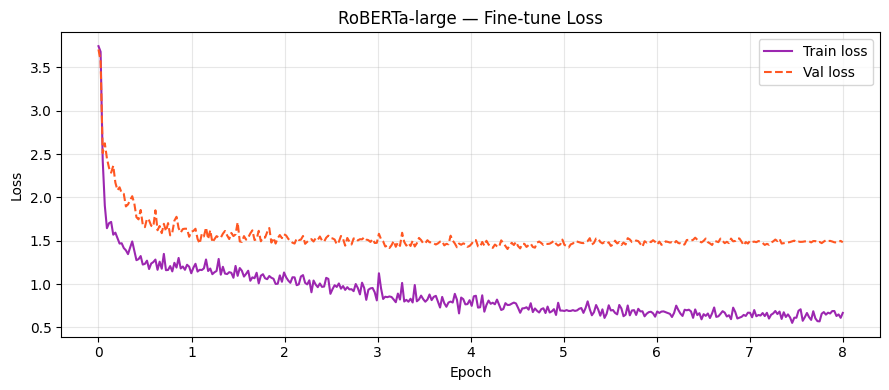

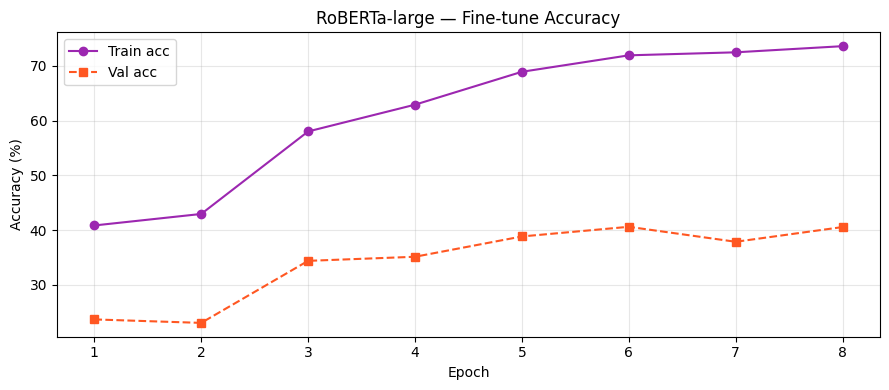

In [11]:
actual_epochs = len(train_accs)

fig, ax = plt.subplots(figsize=(9, 4))
steps_x = np.linspace(0, actual_epochs, len(train_losses))
ax.plot(steps_x, train_losses, label='Train loss', color='#9C27B0')
ax.plot(steps_x, val_losses,   label='Val loss',   color='#FF5722', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('RoBERTa-large — Fine-tune Loss'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roberta_large_loss.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ep_x = range(1, actual_epochs+1)
ax.plot(ep_x, [a*100 for a in train_accs], label='Train acc', color='#9C27B0', marker='o')
ax.plot(ep_x, [a*100 for a in val_accs],   label='Val acc',   color='#FF5722', marker='s', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('RoBERTa-large — Fine-tune Accuracy'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roberta_large_acc.png', dpi=150); plt.show()


## 9 — Load Best Checkpoint & Final Evaluation

In [12]:
ckpt = torch.load(CFG['checkpoint_path'], map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded epoch {ckpt["epoch"]+1}  val_loss {ckpt["val_loss"]:.4f}  '
      f'val_acc {ckpt["val_acc"]*100:.2f}%')

print('\n=== Final Accuracy ===')
for name, loader in [('Train', train_loader), ('Val', val_loader), ('Test', test_loader)]:
    acc = calc_accuracy_loader(loader)
    print(f'  {name:5}: {acc*100:.2f}%')


Loaded epoch 5  val_loss 1.5347  val_acc 38.86%

=== Final Accuracy ===
  Train: 68.41%
  Val  : 38.86%
  Test : 39.54%


## 10 — Per-Class Report & Confusion Matrix

Test set: 100%|██████████| 277/277 [00:42<00:00,  6.47it/s]


              precision    recall  f1-score   support

     Score 1       0.82      0.55      0.66       945
     Score 2       0.23      0.52      0.32       248
     Score 3       0.28      0.53      0.37       396
     Score 4       0.21      0.62      0.31       640
     Score 5       0.93      0.22      0.36      2192

    accuracy                           0.40      4421
   macro avg       0.49      0.49      0.40      4421
weighted avg       0.70      0.40      0.42      4421



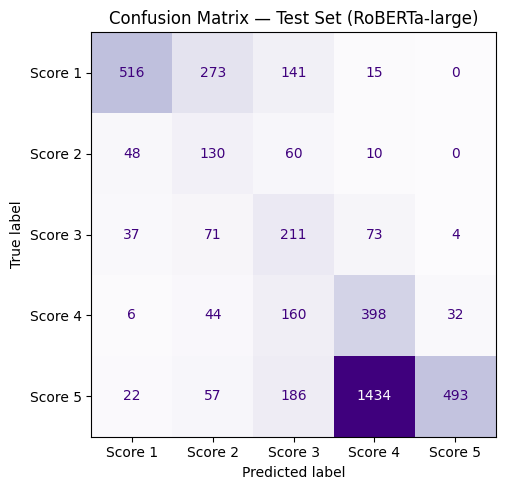

In [13]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for ids, mask, lbl in tqdm(test_loader, desc='Test set'):
        logits = model(ids.to(device), mask.to(device))
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend(lbl.tolist())

target_names = [f'Score {i+1}' for i in range(CFG['num_classes'])]
print(classification_report(all_labels, all_preds, target_names=target_names))

cm  = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
    ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Confusion Matrix — Test Set (RoBERTa-large)')
plt.tight_layout(); plt.savefig('roberta_large_cm.png', dpi=150); plt.show()


## 11 — Save Test Predictions (Real-time, Interrupt-safe)

In [14]:
RESULTS_PATH = CFG['test_results_path']

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f: saved = json.load(f)
    done = {r['sample_index'] for r in saved}
    print(f'Resuming: {len(done)} samples already saved.')
else:
    saved, done = [], set()
    print('Starting fresh.')

model.eval()
global_idx, new_results = 0, []

for ids, mask, lbl in tqdm(test_loader, desc='Saving predictions'):
    B_cur  = ids.size(0)
    to_run = [j for j in range(B_cur) if (global_idx+j) not in done]

    if to_run:
        with torch.no_grad():
            logits = model(ids[to_run].to(device), mask[to_run].to(device))
            probs  = torch.softmax(logits, dim=-1)
            preds  = logits.argmax(-1)

        for k, j in enumerate(to_run):
            idx  = global_idx + j
            row  = test_df.iloc[j]
            true = int(lbl[j].item())
            pred = int(preds[k].item())
            new_results.append({
                'sample_index'   : idx,
                'order_id'       : row.get('order_id',''),
                'text'           : row['text'],
                'true_score'     : true + 1,
                'predicted_score': pred + 1,
                'correct'        : true == pred,
                'confidence'     : round(float(probs[k,pred].item()), 5),
                'all_probs'      : [round(float(p),5) for p in probs[k].tolist()],
            })

        combined = saved + new_results
        tmp = RESULTS_PATH + '.tmp'
        with open(tmp,'w') as f: json.dump(combined, f, indent=2, ensure_ascii=False)
        os.replace(tmp, RESULTS_PATH)

    global_idx += B_cur

all_saved = saved + new_results
n_correct  = sum(r['correct'] for r in all_saved)
print(f'\n{len(all_saved)} predictions saved → {RESULTS_PATH}')
print(f'Accuracy from file: {n_correct/len(all_saved)*100:.2f}%')


Starting fresh.


Saving predictions: 100%|██████████| 277/277 [00:47<00:00,  5.89it/s]


4421 predictions saved → test_results_roberta_large.json
Accuracy from file: 39.54%


## 12 — Per-Score Accuracy Analysis

  Score |   Total |   Correct |      Acc
----------------------------------------
      1 |     945 |       516 |   54.60%
      2 |     248 |       130 |   52.42%
      3 |     396 |       211 |   53.28%
      4 |     640 |       398 |   62.19%
      5 |    2192 |       493 |   22.49%


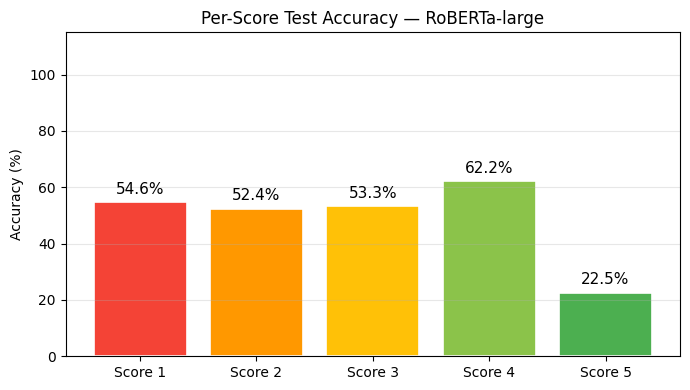

In [15]:
with open(CFG['test_results_path']) as f:
    records = json.load(f)

by_score = {s:{'total':0,'correct':0} for s in range(1,6)}
for r in records:
    s = r['true_score']
    by_score[s]['total']   += 1
    by_score[s]['correct'] += int(r['correct'])

print(f'{'Score':>7} | {'Total':>7} | {'Correct':>9} | {'Acc':>8}')
print('-'*40)
for s in range(1,6):
    t, c = by_score[s]['total'], by_score[s]['correct']
    print(f'{s:>7} | {t:>7} | {c:>9} | {c/t*100:>7.2f}%')

scores = list(range(1,6))
accs   = [by_score[s]['correct']/by_score[s]['total']*100 for s in scores]
colors = ['#f44336','#ff9800','#ffc107','#8bc34a','#4caf50']
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar([f'Score {s}' for s in scores], accs, color=colors, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11)
ax.set_ylim(0,115); ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Score Test Accuracy — RoBERTa-large')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('roberta_large_per_score.png', dpi=150); plt.show()


## 13 — Single Review Inference

In [16]:
def predict(text):
    model.eval()
    enc  = tokenizer(text, max_length=CFG['max_length'],
                     padding='max_length', truncation=True, return_tensors='pt')
    with torch.no_grad():
        probs = torch.softmax(
            model(enc['input_ids'].to(device), enc['attention_mask'].to(device)), dim=-1)[0]
    pred = probs.argmax().item()
    print(f'Text : {text[:100]}')
    print(f'Pred : Score {pred+1}  (conf {probs[pred]*100:.1f}%)')
    for i, p in enumerate(probs.tolist()):
        print(f'  Score {i+1}: {"█"*int(p*30):<30} {p*100:.1f}%')
    return pred + 1

for rev in [
    'The product arrived on time and works perfectly. Very happy!',
    'Terrible quality. Broke after one day. Complete waste of money.',
    'Delivery was late but the product itself is okay.',
]:
    predict(rev); print()


Text : The product arrived on time and works perfectly. Very happy!
Pred : Score 5  (conf 37.4%)
  Score 1:                                1.4%
  Score 2: ████                           15.0%
  Score 3: ███                            10.1%
  Score 4: ██████████                     36.0%
  Score 5: ███████████                    37.4%

Text : Terrible quality. Broke after one day. Complete waste of money.
Pred : Score 1  (conf 93.9%)
  Score 1: ████████████████████████████   93.9%
  Score 2: █                              4.4%
  Score 3:                                1.0%
  Score 4:                                0.5%
  Score 5:                                0.2%

Text : Delivery was late but the product itself is okay.
Pred : Score 3  (conf 87.9%)
  Score 1:                                0.4%
  Score 2:                                1.8%
  Score 3: ██████████████████████████     87.9%
  Score 4: ██                             9.5%
  Score 5:                                0.3%



## 14 — Save Final Model for App

In [17]:
save_dir  = '/home/labib/Desktop/labib_codes/uiu_codes/7th_trimester/da_project/da_project_local/notebooks/nlp_evaluation/bert/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'roberta_large_review_best.pt')
import shutil
shutil.copy(CFG['checkpoint_path'], save_path)
print(f'✅ Saved to: {save_path}')


✅ Saved to: /home/labib/Desktop/labib_codes/uiu_codes/7th_trimester/da_project/da_project_local/notebooks/nlp_evaluation/bert/roberta_large_review_best.pt
